# Prototype for FDA_C&D 

A function enabling Fourier Domain Adaptation with a module for conditional selection and a module for distributional matching.

To be transformed into a Python file.

## Requirements

In [ ]:
import numpy as np
import deeplake
import os
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import random
from datetime import datetime
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor
import joblib
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

LABEL_MAP = {
    "Stroma": 0,
    "Normal": 1,
    "G3":     2,
    "G4":     3,
    "G5":     4
}

REVERSE_LABEL_MAP = {0: "Stroma",
    1: "Normal", 
    2: "G3",
    3: "G4",
    4: "G5"
}

classifier = joblib.load("/home/leolr-int/nfs/transformed_data/weights/random_forest.pkl")
distrib_Akoya = joblib.load("/home/leolr-int/nfs/transformed_data/weights/cdf_Akoya.pkl")
distrib_KFBio = joblib.load("/home/leolr-int/nfs/transformed_data/weights/cdf_KFBio.pkl")

# the distribution of KFBio should be calculated during inference: in real-life usage, 
# the WSI will be given and the distribution of low amplitudes from patches should be calculated over this image only 

## Pipeline

Variables

In [ ]:
# fetching data (deeplake dataset)
dataset_path_KFbio_1 = f"/home/leolr-int/nfs/data/data/patched/dim_256/Train/Subset3_Train_1_KFBio"
KFBio_1 = deeplake.open_read_only(dataset_path_KFbio_1)

#because previoulsy the matched ampltude was for the first element of KFBio log amplitudes matrix, which means the first patch of the first WSI of KFBio
src_img = KFBio_1[0]["patch"].transpose((2, 0, 1))  # (3, 256, 256)

Extracting the vector

In [ ]:
def Flat_log_Fourier(src_image, L=0.01):
    
    # Compute FFT of the source image
    fft_src = np.fft.fft2(src_image, axes=(-2, -1))
    amp_src = np.abs(fft_src)
    phase_src = np.angle(fft_src)

    # Shift amplitude spectra to center the low-frequency components
    amp_src = np.fft.fftshift(amp_src, axes=(-2, -1))

    # Defining the square of low amplitudes to be swapped
    _, height, width = amp_src.shape
    radius = int(np.floor(min(height, width) * L))
    center_h = height // 2
    center_w = width // 2

    h_start, h_end = center_h - radius, center_h + radius + 1
    w_start, w_end = center_w - radius, center_w + radius + 1

    small_amp = amp_src[:, h_start:h_end, w_start:w_end]

    return np.log(small_amp.reshape(-1))

dataset_path_akoya_1 = f"/home/leolr-int/nfs/data/data/patched/dim_256/Train/Subset3_Train_1_Akoya"
akoya_1 = deeplake.open_read_only(dataset_path_akoya_1)

# Preprocessing
vector = Flat_log_Fourier(src_img)
print(vector.shape)


(75,)


Predict the label

In [16]:

pred_label = int(classifier.predict(vector.reshape(1, -1))) 
# because transposition happened during creation of amplitudes dataset
print(pred_label)
print(KFBio_1[0]["label"])

2
3


/tmp/ipykernel_1720426/3582865729.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label = int(classifier.predict(vector.reshape(1, -1)))


Matching the vector

In [ ]:
def match_vector_to_target_distribution(vector, source_cdfs, target_cdfs):
    """
    Transforms a 75-dimensional vector from source distribution to match the target distribution.
    
    Parameters:
    - vector: np.ndarray of shape (75,)
    - source_cdfs: dict[label][feature_index] = (xs, cdf_vals)
    - target_cdfs: same structure as source_cdfs
    - Returns: transformed vector (np.ndarray of shape (75,))
    """
    #assert vector.shape[0] == 75, "Input vector must have 75 dimensions"

    transformed_vector = np.zeros_like(vector)

    for i in range(75):
        xs_src, cdf_src = source_cdfs[i]
        xs_tgt, cdf_tgt = target_cdfs[i]

        # Interpolator for source: value -> probability
        cdf_interp_src = interp1d(xs_src, cdf_src, bounds_error=False, fill_value=(0.0, 1.0))

        # Interpolator for target: probability -> value
        inv_cdf_interp_tgt = interp1d(cdf_tgt, xs_tgt, bounds_error=False, fill_value="extrapolate")

        # Step 1: get cumulative probability of vector[i] under source
        p = float(cdf_interp_src(vector[i]))

        # Step 2: map to value under target
        x_new = float(inv_cdf_interp_tgt(p))

        transformed_vector[i] = x_new

    return transformed_vector




src_cdfs = distrib_KFBio[pred_label]
tgt_cdfs = distrib_Akoya[pred_label]

vector_KFBio_to_Akoya = match_vector_to_target_distribution(vector, src_cdfs, tgt_cdfs)

print(vector_KFBio_to_Akoya)




[10.71943927 11.19516421 11.0780606  11.1803724   9.15119274 10.57318935
  9.16647598 11.91979665 11.10326984 10.77970756 11.08219106 10.41791571
 16.56916363 10.41791571 11.08219106 10.77970756 11.10326984 11.91979665
  9.16647598 10.57318935  9.15119274 11.1803724  11.0780606  11.19516421
 10.71943927 12.48765877 11.93195142 12.68973323 12.26519351 11.74732079
 11.76383563 12.12342791 13.02625927 11.66784591 11.35121986 11.49560818
 11.47888205 16.13994724 11.47888205 11.49560818 11.35121986 11.66784591
 13.02625927 12.12342791 11.76383563 11.74732079 12.26519351 12.68973323
 11.93195142 12.48765877 11.44843769 10.79009744 11.7327542  11.24476905
 10.69607974 10.62291278 11.15348988 11.9056594  10.76839553 10.30596464
 10.18986823 10.97253177 16.4468771  10.97253177 10.18986823 10.30596464
 10.76839553 11.9056594  11.15348988 10.62291278 10.69607974 11.24476905
 11.7327542  10.79009744 11.44843769]


Transforming the image

In [31]:
def get_white_pixel_mask(image, white_thresh=200):
    """
    Returns a binary mask of white pixels.
    Input: image (C, H, W), RGB
    Output: mask (H, W), dtype=bool
    """
    img = np.transpose(image, (1, 2, 0))  # to HWC
    #designates the pixel as white if and only if all three colors are above 200
    return np.all(img > white_thresh, axis=-1)

def new_FDA(src_image, amp_matched, L=0.01, save=False, output_folder="", display=False):
    
    # Store mask to apply it to the output
    white_mask = get_white_pixel_mask(src_image, white_thresh=200)  # (H, W) coordinates of white pixel
    white_pixel_values = src_image[:, white_mask]  # shape: (C, N_white_pixels)

    # reference point, average amplitude from Akoya
    target_amplitude = np.load("/home/leolr-int/nfs/ASTAR_internship/Fourier_Domain_Adaptation/stored_amplitude/general_average_akoya.npy")

    # Compute FFT of the source image
    fft_src = np.fft.fft2(src_image, axes=(-2, -1))
    amp_src = np.abs(fft_src)
    phase_src = np.angle(fft_src)

    # Shift amplitude spectra to center the low-frequency components
    amp_src = np.fft.fftshift(amp_src, axes=(-2, -1))
    target_amplitude = np.fft.fftshift(target_amplitude, axes=(-2, -1))

    # Defining the square of low amplitudes to be swapped
    _, height, width = amp_src.shape
    radius = int(np.floor(min(height, width) * L))
    center_h = height // 2
    center_w = width // 2

    h_start, h_end = center_h - radius, center_h + radius + 1
    w_start, w_end = center_w - radius, center_w + radius + 1

    ## Change here with the new vector of amplitudes!
    
    #exponential is important because i have used logarithms 
    amp_src[:, h_start:h_end, w_start:w_end] = np.exp(amp_matched.reshape(3,5,5))
    
    amp_src = np.fft.ifftshift(amp_src, axes=(-2, -1))

    # Reconstruct the adapted image
    adapted_fft = amp_src * np.exp(1j * phase_src)
    adapted_image = np.fft.ifft2(adapted_fft, axes=(-2, -1)).real

    # Clip to valid range and convert to uint8 for correct visualisation
    adapted_image = np.clip(adapted_image, 0, 255).astype(np.uint8)

    # Put white pixels from original image back in FDA output
    for c in range(src_image.shape[0]):
        channel = adapted_image[c]
        channel[white_mask] = white_pixel_values[c]
        adapted_image[c] = channel

    # saving picture
    if save:
        os.makedirs(output_folder, exist_ok=True)
        filename = f"WFDA_L_{L}.png"
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(src_image.transpose((1, 2, 0)).astype(np.uint8))
        axes[0].set_title("Source")
        axes[1].imshow(adapted_image.transpose((1, 2, 0)))
        axes[1].set_title("FWDA → Akoya")
        plt.suptitle(f"Fourier Domain Adaptation with white filter and amplitude distribution matching to Akoya L={L}")
        plt.savefig(os.path.join(output_folder, filename))
        plt.close(fig)
    
    if display:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(src_image.transpose((1, 2, 0)).astype(np.uint8))
        axes[0].set_title("Source")
        axes[1].imshow(adapted_image.transpose((1, 2, 0)))
        axes[1].set_title("WFDA → Akoya")
        plt.suptitle(f"Fourier Domain Adaptation with white filter and amplitude distribution matching to Akoya L={L}")
        plt.show()

    return adapted_image

Test

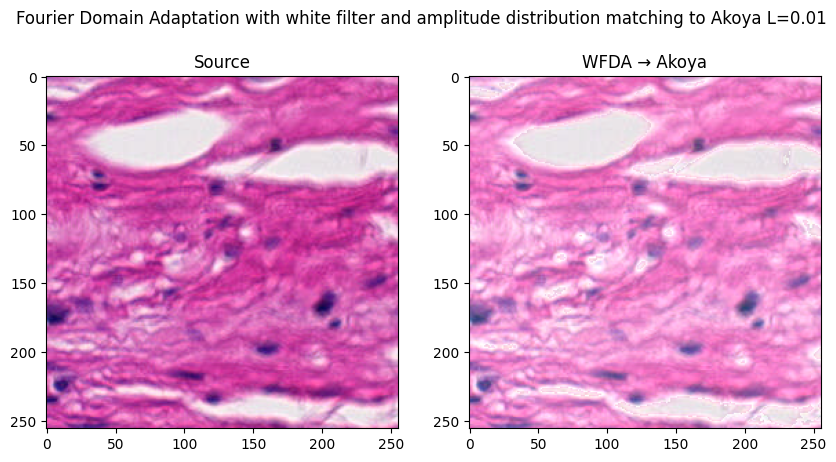

array([[[205, 205, 208, ..., 255, 255, 255],
        [198, 199, 204, ..., 255, 255, 255],
        [200, 203, 207, ..., 255, 255, 255],
        ...,
        [217, 221, 230, ..., 255, 255, 255],
        [229, 231, 234, ..., 241, 238, 238],
        [234, 232, 227, ..., 223, 214, 210]],

       [[133, 130, 129, ..., 185, 190, 195],
        [136, 137, 140, ..., 185, 185, 188],
        [145, 149, 154, ..., 194, 196, 199],
        ...,
        [129, 127, 127, ..., 199, 204, 212],
        [124, 122, 120, ..., 178, 174, 174],
        [ 95,  95,  99, ..., 151, 146, 141]],

       [[206, 199, 196, ..., 228, 232, 235],
        [208, 204, 204, ..., 233, 235, 237],
        [216, 215, 215, ..., 238, 237, 237],
        ...,
        [197, 198, 201, ..., 234, 231, 231],
        [179, 184, 193, ..., 220, 216, 216],
        [192, 192, 191, ..., 196, 198, 202]]],
      shape=(3, 256, 256), dtype=uint8)

In [35]:
new_FDA(src_img, vector_KFBio_to_Akoya, L=0.01, save=False, output_folder="", display=True)

In [ ]:
# Test with Python function 

# fetching data (deeplake dataset)
dataset_path_KFbio_1 = f"/home/leolr-int/nfs/data/data/patched/dim_256/Train/Subset3_Train_1_KFBio"
KFBio_1 = deeplake.open_read_only(dataset_path_KFbio_1)

#because previoulsy the matched ampltude was for the first element of KFBio log amplitudes matrix, which means the first patch of the first WSI of KFBio
src_img = KFBio_1[0]["patch"].transpose((2, 0, 1))  # (3, 256, 256)


from FDA_CD import FDA_CD
FDA_CD(src_img, True, True)